In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/priyamtiwari948/syngenta-hackathon-dataset/growers.csv
/kaggle/input/datasets/priyamtiwari948/syngenta-hackathon-dataset/digital_funnel_weekly.csv
/kaggle/input/datasets/priyamtiwari948/syngenta-hackathon-dataset/retailers.csv
/kaggle/input/datasets/priyamtiwari948/syngenta-hackathon-dataset/reps_territory.csv
/kaggle/input/datasets/priyamtiwari948/syngenta-hackathon-dataset/retailer_pos.csv
/kaggle/input/datasets/priyamtiwari948/syngenta-hackathon-dataset/retailer_visit_log.csv
/kaggle/input/datasets/priyamtiwari948/syngenta-hackathon-dataset/DATA_DICTIONARY.md
/kaggle/input/datasets/priyamtiwari948/syngenta-hackathon-dataset/whatsapp_campaign.csv
/kaggle/input/datasets/priyamtiwari948/syngenta-hackathon-dataset/retailer_inventory_weekly.csv


# Import Libraries

In [2]:
import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, classification_report, confusion_matrix

# Check Dataset Files

In [3]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/priyamtiwari948/syngenta-hackathon-dataset/growers.csv
/kaggle/input/datasets/priyamtiwari948/syngenta-hackathon-dataset/digital_funnel_weekly.csv
/kaggle/input/datasets/priyamtiwari948/syngenta-hackathon-dataset/retailers.csv
/kaggle/input/datasets/priyamtiwari948/syngenta-hackathon-dataset/reps_territory.csv
/kaggle/input/datasets/priyamtiwari948/syngenta-hackathon-dataset/retailer_pos.csv
/kaggle/input/datasets/priyamtiwari948/syngenta-hackathon-dataset/retailer_visit_log.csv
/kaggle/input/datasets/priyamtiwari948/syngenta-hackathon-dataset/DATA_DICTIONARY.md
/kaggle/input/datasets/priyamtiwari948/syngenta-hackathon-dataset/whatsapp_campaign.csv
/kaggle/input/datasets/priyamtiwari948/syngenta-hackathon-dataset/retailer_inventory_weekly.csv


# Set Dataset Path

In [4]:
data_path = "/kaggle/input/datasets/priyamtiwari948/syngenta-hackathon-dataset"

print(os.listdir(data_path))

['growers.csv', 'digital_funnel_weekly.csv', 'retailers.csv', 'reps_territory.csv', 'retailer_pos.csv', 'retailer_visit_log.csv', 'DATA_DICTIONARY.md', 'whatsapp_campaign.csv', 'retailer_inventory_weekly.csv']


# Load CSV Files

In [5]:
growers = pd.read_csv(f"{data_path}/growers.csv")
retailers = pd.read_csv(f"{data_path}/retailers.csv")
reps = pd.read_csv(f"{data_path}/reps_territory.csv")
visits = pd.read_csv(f"{data_path}/retailer_visit_log.csv")
inventory = pd.read_csv(f"{data_path}/retailer_inventory_weekly.csv")
pos = pd.read_csv(f"{data_path}/retailer_pos.csv")
whatsapp = pd.read_csv(f"{data_path}/whatsapp_campaign.csv")
digital = pd.read_csv(f"{data_path}/digital_funnel_weekly.csv")

print("Data loaded successfully")

Data loaded successfully


# Shape of All DataFrames

In [6]:
print("Growers:", growers.shape)
print("Retailers:", retailers.shape)
print("Reps:", reps.shape)
print("Visits:", visits.shape)
print("Inventory:", inventory.shape)
print("POS:", pos.shape)
print("WhatsApp:", whatsapp.shape)
print("Digital:", digital.shape)

Growers: (6000, 15)
Retailers: (4000, 5)
Reps: (500, 6)
Visits: (30000, 6)
Inventory: (310544, 5)
POS: (235042, 7)
WhatsApp: (4479, 8)
Digital: (104, 7)


# Check Columns

In [7]:
print("Growers columns:", growers.columns.tolist())
print("Retailers columns:", retailers.columns.tolist())
print("Reps columns:", reps.columns.tolist())
print("Visits columns:", visits.columns.tolist())
print("Inventory columns:", inventory.columns.tolist())
print("POS columns:", pos.columns.tolist())
print("WhatsApp columns:", whatsapp.columns.tolist())
print("Digital columns:", digital.columns.tolist())

Growers columns: ['grower_id', 'state', 'district', 'tehsil', 'language', 'device_type', 'grower_age', 'gender', 'grower_crop_calendar', 'product_scan', 'product_name', 'product_scan_datetime', 'grower_farm_size', 'offline_campaign_attended', 'campaign_attendance_date']
Retailers columns: ['retailer_id', 'territory_id', 'state', 'district', 'tehsil']
Reps columns: ['rep_id', 'territory_id', 'territory_name', 'state', 'district', 'tehsil_list']
Visits columns: ['rep_id', 'visit_date', 'territory_id', 'visit_tehsil', 'visit_type', 'product_recommended']
Inventory columns: ['retailer_id', 'sku_id', 'sku_name', 'sku_qty', 'week_end_date']
POS columns: ['retailer_id', 'transaction_id', 'sku_id', 'sku_name', 'sku_qty', 'sku_price', 'transaction_date']
WhatsApp columns: ['id', 'campaign_product', 'campaign_crop', 'grower_id', 'message_sent_date', 'delivered_status', 'opened_status', 'clicked_status']
Digital columns: ['campaign_id', 'week_start_date', 'social_post_impression', 'landing_page_v

# Preview Important Tables

In [8]:
display(retailers.head())
display(pos.head())
display(inventory.head())
display(visits.head())

,retailer_id,territory_id,state,district,tehsil
0,RTL_00001,TER_0001,Bihar,Patna,Patna_T012
1,RTL_00002,TER_0001,Bihar,Patna,Patna_T004
2,RTL_00003,TER_0001,Bihar,Patna,Patna_T002
3,RTL_00004,TER_0001,Bihar,Patna,Patna_T007
4,RTL_00005,TER_0001,Bihar,Patna,Patna_T007


,retailer_id,transaction_id,sku_id,sku_name,sku_qty,sku_price,transaction_date
0,RTL_00001,POS_f457022d4d51,SY_SCO_250EC,Score 250 EC,81,1539.21,2025-10-10
1,RTL_00001,POS_f2f5eaaaf5e4,SY_SCO_250EC,Score 250 EC,3,1644.39,2025-10-14
2,RTL_00001,POS_94af270ca790,SY_AXI_50EC,Axial 50 EC,1,393.85,2025-10-18
3,RTL_00001,POS_a6e6345ef25c,SY_AXI_50EC,Axial 50 EC,1,1257.72,2025-10-18
4,RTL_00001,POS_3dfd7d3a4837,SY_AXI_50EC,Axial 50 EC,1,1028.55,2025-10-16


,retailer_id,sku_id,sku_name,sku_qty,week_end_date
0,RTL_00001,SY_TILT_250EC,Tilt 250 EC,94,2025-10-05
1,RTL_00001,SY_SCO_250EC,Score 250 EC,122,2025-10-05
2,RTL_00001,SY_AXI_50EC,Axial 50 EC,193,2025-10-05
3,RTL_00001,SY_TILT_250EC,Tilt 250 EC,94,2025-10-12
4,RTL_00001,SY_SCO_250EC,Score 250 EC,41,2025-10-12


,rep_id,visit_date,territory_id,visit_tehsil,visit_type,product_recommended
0,REP_0203,2026-03-09,TER_0203,Jalgaon_T062,retailer meeting,Vertimec 1.8 EC
1,REP_0203,2026-03-12,TER_0203,Jalgaon_T064,retailer meeting,Tilt 250 EC
2,REP_0203,2026-03-12,TER_0203,Jalgaon_T063,campaign_conducted,Cruiser 350 FS
3,REP_0203,2026-03-12,TER_0203,Jalgaon_T064,retailer meeting,Cruiser 350 FS
4,REP_0203,2026-03-12,TER_0203,Jalgaon_T063,campaign_conducted,Tilt 250 EC


# Check Missing Values

In [9]:
datasets = {
    "growers": growers,
    "retailers": retailers,
    "reps": reps,
    "visits": visits,
    "inventory": inventory,
    "pos": pos,
    "whatsapp": whatsapp,
    "digital": digital
}

for name, df in datasets.items():
    print("\n", name)
    print(df.isnull().sum())


 growers
grower_id                       0
state                           0
district                        0
tehsil                          0
language                        0
device_type                     0
grower_age                      0
gender                          0
grower_crop_calendar          450
product_scan                    0
product_name                 4904
product_scan_datetime        4843
grower_farm_size              745
offline_campaign_attended       0
campaign_attendance_date     2078
dtype: int64

 retailers
retailer_id     0
territory_id    0
state           0
district        0
tehsil          0
dtype: int64

 reps
rep_id            0
territory_id      0
territory_name    0
state             0
district          0
tehsil_list       0
dtype: int64

 visits
rep_id                 0
visit_date             0
territory_id           0
visit_tehsil           0
visit_type             0
product_recommended    0
dtype: int64

 inventory
retailer_id      0
sku_id   

# Convert Date Columns

In [10]:
visits["visit_date"] = pd.to_datetime(visits["visit_date"], errors="coerce")
inventory["week_end_date"] = pd.to_datetime(inventory["week_end_date"], errors="coerce")
pos["transaction_date"] = pd.to_datetime(pos["transaction_date"], errors="coerce")
whatsapp["message_sent_date"] = pd.to_datetime(whatsapp["message_sent_date"], errors="coerce")
digital["week_start_date"] = pd.to_datetime(digital["week_start_date"], errors="coerce")
growers["product_scan_datetime"] = pd.to_datetime(growers["product_scan_datetime"], errors="coerce")
growers["campaign_attendance_date"] = pd.to_datetime(growers["campaign_attendance_date"], errors="coerce")

print("Date conversion completed")

Date conversion completed


# Latest Reference Date

In [11]:
latest_date = max(
    visits["visit_date"].max(),
    inventory["week_end_date"].max(),
    pos["transaction_date"].max(),
    whatsapp["message_sent_date"].max(),
    digital["week_start_date"].max()
)

print("Latest date in dataset:", latest_date)

Latest date in dataset: 2026-04-05 00:00:00


# Master Table

In [12]:
master = retailers.copy()

print("Master table shape:", master.shape)
display(master.head())

Master table shape: (4000, 5)


,retailer_id,territory_id,state,district,tehsil
0,RTL_00001,TER_0001,Bihar,Patna,Patna_T012
1,RTL_00002,TER_0001,Bihar,Patna,Patna_T004
2,RTL_00003,TER_0001,Bihar,Patna,Patna_T002
3,RTL_00004,TER_0001,Bihar,Patna,Patna_T007
4,RTL_00005,TER_0001,Bihar,Patna,Patna_T007


# Last Visit Gap Feature

In [13]:
last_visit = visits.groupby(["territory_id", "visit_tehsil"])["visit_date"].max().reset_index()

last_visit.rename(
    columns={
        "visit_tehsil": "tehsil",
        "visit_date": "last_visit_date"
    },
    inplace=True
)

master = master.merge(last_visit, on=["territory_id", "tehsil"], how="left")

master["last_visit_days"] = (latest_date - master["last_visit_date"]).dt.days
master["last_visit_days"] = master["last_visit_days"].fillna(999)

display(master[["retailer_id", "territory_id", "tehsil", "last_visit_date", "last_visit_days"]].head())

,retailer_id,territory_id,tehsil,last_visit_date,last_visit_days
0,RTL_00001,TER_0001,Patna_T012,2026-03-13,23.0
1,RTL_00002,TER_0001,Patna_T004,2026-03-15,21.0
2,RTL_00003,TER_0001,Patna_T002,2026-03-15,21.0
3,RTL_00004,TER_0001,Patna_T007,2026-03-12,24.0
4,RTL_00005,TER_0001,Patna_T007,2026-03-12,24.0


# Sales Features

In [14]:
pos["sales_value"] = pos["sku_qty"] * pos["sku_price"]

last_30_days = latest_date - pd.Timedelta(days=30)
last_7_days = latest_date - pd.Timedelta(days=7)

sales_30 = pos[pos["transaction_date"] >= last_30_days].groupby("retailer_id").agg(
    sales_qty_30=("sku_qty", "sum"),
    sales_value_30=("sales_value", "sum"),
    transactions_30=("transaction_id", "nunique")
).reset_index()

sales_7 = pos[pos["transaction_date"] >= last_7_days].groupby("retailer_id").agg(
    sales_qty_7=("sku_qty", "sum"),
    sales_value_7=("sales_value", "sum"),
    transactions_7=("transaction_id", "nunique")
).reset_index()

master = master.merge(sales_30, on="retailer_id", how="left")
master = master.merge(sales_7, on="retailer_id", how="left")

sales_cols = [
    "sales_qty_30",
    "sales_value_30",
    "transactions_30",
    "sales_qty_7",
    "sales_value_7",
    "transactions_7"
]

for col in sales_cols:
    master[col] = master[col].fillna(0)

master["sales_growth_ratio"] = master["sales_qty_7"] / (master["sales_qty_30"] + 1)

display(master[["retailer_id", "sales_qty_30", "sales_qty_7", "sales_growth_ratio"]].head())

,retailer_id,sales_qty_30,sales_qty_7,sales_growth_ratio
0,RTL_00001,44.0,0.0,0.000000
1,RTL_00002,36.0,0.0,0.000000
2,RTL_00003,88.0,1.0,0.011236
3,RTL_00004,119.0,0.0,0.000000
4,RTL_00005,24.0,0.0,0.000000


# Inventory / Stock Features

In [15]:
latest_inventory_date = inventory["week_end_date"].max()

latest_inventory = inventory[inventory["week_end_date"] == latest_inventory_date]

inventory_summary = latest_inventory.groupby("retailer_id").agg(
    total_stock_qty=("sku_qty", "sum"),
    unique_skus=("sku_id", "nunique")
).reset_index()

master = master.merge(inventory_summary, on="retailer_id", how="left")

master["total_stock_qty"] = master["total_stock_qty"].fillna(0)
master["unique_skus"] = master["unique_skus"].fillna(0)

def stock_status(qty):
    if qty <= 0:
        return "Out of Stock"
    elif qty <= 20:
        return "Low Stock"
    elif qty <= 50:
        return "Medium Stock"
    else:
        return "Good Stock"

master["stock_status"] = master["total_stock_qty"].apply(stock_status)

display(master[["retailer_id", "total_stock_qty", "unique_skus", "stock_status"]].head())

,retailer_id,total_stock_qty,unique_skus,stock_status
0,RTL_00001,163,3,Good Stock
1,RTL_00002,72,4,Good Stock
2,RTL_00003,124,3,Good Stock
3,RTL_00004,192,3,Good Stock
4,RTL_00005,128,2,Good Stock


# Recommended Product Feature

In [16]:
product_demand = pos[pos["transaction_date"] >= last_30_days].groupby(
    ["retailer_id", "sku_id", "sku_name"]
).agg(
    product_sales_qty_30=("sku_qty", "sum"),
    product_sales_value_30=("sales_value", "sum")
).reset_index()

top_product = product_demand.sort_values(
    ["retailer_id", "product_sales_qty_30"],
    ascending=[True, False]
).drop_duplicates("retailer_id")

top_product = top_product[
    ["retailer_id", "sku_id", "sku_name", "product_sales_qty_30"]
]

top_product.rename(
    columns={
        "sku_id": "recommended_sku_id",
        "sku_name": "recommended_product"
    },
    inplace=True
)

master = master.merge(top_product, on="retailer_id", how="left")

master["recommended_sku_id"] = master["recommended_sku_id"].fillna("NA")
master["recommended_product"] = master["recommended_product"].fillna("General Crop Protection Product")
master["product_sales_qty_30"] = master["product_sales_qty_30"].fillna(0)

display(master[["retailer_id", "recommended_product", "product_sales_qty_30"]].head())

,retailer_id,recommended_product,product_sales_qty_30
0,RTL_00001,Tilt 250 EC,26.0
1,RTL_00002,Axial 50 EC,17.0
2,RTL_00003,Cruiser 350 FS,46.0
3,RTL_00004,Amistar 250 SC,97.0
4,RTL_00005,Movondo,13.0


# Grower Density Features

In [17]:
grower_density = growers.groupby(["state", "district", "tehsil"]).agg(
    grower_count=("grower_id", "nunique"),
    avg_farm_size=("grower_farm_size", "mean"),
    product_scans=("product_scan", "sum"),
    campaign_attendance=("offline_campaign_attended", "sum")
).reset_index()

master = master.merge(grower_density, on=["state", "district", "tehsil"], how="left")

grower_cols = [
    "grower_count",
    "avg_farm_size",
    "product_scans",
    "campaign_attendance"
]

for col in grower_cols:
    master[col] = master[col].fillna(0)

display(master[["retailer_id", "tehsil", "grower_count", "avg_farm_size", "product_scans", "campaign_attendance"]].head())

,retailer_id,tehsil,grower_count,avg_farm_size,product_scans,campaign_attendance
0,RTL_00001,Patna_T012,1.0,2.87,0.0,1.0
1,RTL_00002,Patna_T004,3.0,1.23,0.0,3.0
2,RTL_00003,Patna_T002,1.0,1.38,0.0,1.0
3,RTL_00004,Patna_T007,0.0,0.00,0.0,0.0
4,RTL_00005,Patna_T007,0.0,0.00,0.0,0.0


# WhatsApp Engagement Features

In [18]:
whatsapp_engagement = whatsapp.groupby("grower_id").agg(
    messages_sent=("id", "count"),
    delivered=("delivered_status", "sum"),
    opened=("opened_status", "sum"),
    clicked=("clicked_status", "sum")
).reset_index()

growers_eng = growers.merge(whatsapp_engagement, on="grower_id", how="left")

for col in ["messages_sent", "delivered", "opened", "clicked"]:
    growers_eng[col] = growers_eng[col].fillna(0)

tehsil_engagement = growers_eng.groupby(["state", "district", "tehsil"]).agg(
    total_messages=("messages_sent", "sum"),
    total_opened=("opened", "sum"),
    total_clicked=("clicked", "sum")
).reset_index()

master = master.merge(tehsil_engagement, on=["state", "district", "tehsil"], how="left")

for col in ["total_messages", "total_opened", "total_clicked"]:
    master[col] = master[col].fillna(0)

master["engagement_rate"] = master["total_clicked"] / (master["total_messages"] + 1)

display(master[["retailer_id", "total_messages", "total_opened", "total_clicked", "engagement_rate"]].head())

,retailer_id,total_messages,total_opened,total_clicked,engagement_rate
0,RTL_00001,1.0,0.0,0.0,0.0
1,RTL_00002,1.0,1.0,0.0,0.0
2,RTL_00003,1.0,0.0,0.0,0.0
3,RTL_00004,0.0,0.0,0.0,0.0
4,RTL_00005,0.0,0.0,0.0,0.0


# Master Table

In [19]:
print("Master table shape:", master.shape)

display(master.head())

print("\nMissing values in master:")
print(master.isnull().sum())

Master table shape: (4000, 28)


,retailer_id,territory_id,state,district,tehsil,last_visit_date,last_visit_days,sales_qty_30,sales_value_30,transactions_30,...,recommended_product,product_sales_qty_30,grower_count,avg_farm_size,product_scans,campaign_attendance,total_messages,total_opened,total_clicked,engagement_rate
0,RTL_00001,TER_0001,Bihar,Patna,Patna_T012,2026-03-13,23.0,44.0,77152.58,8.0,...,Tilt 250 EC,26.0,1.0,2.87,0.0,1.0,1.0,0.0,0.0,0.0
1,RTL_00002,TER_0001,Bihar,Patna,Patna_T004,2026-03-15,21.0,36.0,47937.96,13.0,...,Axial 50 EC,17.0,3.0,1.23,0.0,3.0,1.0,1.0,0.0,0.0
2,RTL_00003,TER_0001,Bihar,Patna,Patna_T002,2026-03-15,21.0,88.0,89680.03,11.0,...,Cruiser 350 FS,46.0,1.0,1.38,0.0,1.0,1.0,0.0,0.0,0.0
3,RTL_00004,TER_0001,Bihar,Patna,Patna_T007,2026-03-12,24.0,119.0,156378.53,12.0,...,Amistar 250 SC,97.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0
4,RTL_00005,TER_0001,Bihar,Patna,Patna_T007,2026-03-12,24.0,24.0,38468.35,6.0,...,Movondo,13.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0



Missing values in master:
retailer_id              0
territory_id             0
state                    0
district                 0
tehsil                   0
last_visit_date         68
last_visit_days          0
sales_qty_30             0
sales_value_30           0
transactions_30          0
sales_qty_7              0
sales_value_7            0
transactions_7           0
sales_growth_ratio       0
total_stock_qty          0
unique_skus              0
stock_status             0
recommended_sku_id       0
recommended_product      0
product_sales_qty_30     0
grower_count             0
avg_farm_size            0
product_scans            0
campaign_attendance      0
total_messages           0
total_opened             0
total_clicked            0
engagement_rate          0
dtype: int64


# Score Normalization Function

In [20]:
def normalize_score(series):
    if series.max() == series.min():
        return pd.Series([50] * len(series), index=series.index)
    return ((series - series.min()) / (series.max() - series.min()) * 100)

# Individual Scores

In [21]:
master["sales_demand_score"] = normalize_score(
    master["sales_qty_30"] + master["sales_qty_7"] * 2
)

master["stock_alert_score"] = 100 - normalize_score(
    master["total_stock_qty"]
)

master["last_visit_gap_score"] = normalize_score(
    master["last_visit_days"].clip(upper=60)
)

master["product_relevance_score"] = normalize_score(
    master["product_sales_qty_30"]
)

master["grower_engagement_score"] = normalize_score(
    master["grower_count"] + master["engagement_rate"] * 100
)

score_cols = [
    "sales_demand_score",
    "stock_alert_score",
    "last_visit_gap_score",
    "product_relevance_score",
    "grower_engagement_score"
]

display(master[["retailer_id"] + score_cols].head())

,retailer_id,sales_demand_score,stock_alert_score,last_visit_gap_score,product_relevance_score,grower_engagement_score
0,RTL_00001,6.136681,77.853261,30.188679,8.904110,1.785714
1,RTL_00002,5.020921,90.217391,26.415094,5.821918,5.357143
2,RTL_00003,12.552301,83.152174,26.415094,15.753425,1.785714
3,RTL_00004,16.596932,73.913043,32.075472,33.219178,0.000000
4,RTL_00005,3.347280,82.608696,32.075472,4.452055,0.000000


# Final Visit Priority Score

In [22]:
master["visit_priority_score"] = (
    0.30 * master["sales_demand_score"] +
    0.25 * master["stock_alert_score"] +
    0.20 * master["last_visit_gap_score"] +
    0.15 * master["product_relevance_score"] +
    0.10 * master["grower_engagement_score"]
)

display(master[["retailer_id", "visit_priority_score"]].head())

,retailer_id,visit_priority_score
0,RTL_00001,28.856243
1,RTL_00002,30.752645
2,RTL_00003,32.378338
3,RTL_00004,34.855311
4,RTL_00005,28.739261


# Priority Level

In [23]:
high_threshold = master["visit_priority_score"].quantile(0.80)
medium_threshold = master["visit_priority_score"].quantile(0.50)

print("High threshold:", high_threshold)
print("Medium threshold:", medium_threshold)

def priority_level(score):
    if score >= high_threshold:
        return "High"
    elif score >= medium_threshold:
        return "Medium"
    else:
        return "Low"

master["priority_level"] = master["visit_priority_score"].apply(priority_level)

print(master["priority_level"].value_counts())

display(master[["retailer_id", "visit_priority_score", "priority_level"]].head())

High threshold: 43.760621178566474
Medium threshold: 35.32183684718859
priority_level
Low       2000
Medium    1200
High       800
Name: count, dtype: int64


,retailer_id,visit_priority_score,priority_level
0,RTL_00001,28.856243,Low
1,RTL_00002,30.752645,Low
2,RTL_00003,32.378338,Low
3,RTL_00004,34.855311,Low
4,RTL_00005,28.739261,Low


# Recommended Action

In [24]:
def generate_action(row):
    if row["priority_level"] == "High":
        return f"Visit retailer urgently and discuss restocking of {row['recommended_product']}."
    elif row["priority_level"] == "Medium":
        return f"Plan visit this week and check demand for {row['recommended_product']}."
    else:
        return "Monitor retailer and schedule visit later."

master["recommended_action"] = master.apply(generate_action, axis=1)

display(master[["retailer_id", "priority_level", "recommended_product", "recommended_action"]].head())

,retailer_id,priority_level,recommended_product,recommended_action
0,RTL_00001,Low,Tilt 250 EC,Monitor retailer and schedule visit later.
1,RTL_00002,Low,Axial 50 EC,Monitor retailer and schedule visit later.
2,RTL_00003,Low,Cruiser 350 FS,Monitor retailer and schedule visit later.
3,RTL_00004,Low,Amistar 250 SC,Monitor retailer and schedule visit later.
4,RTL_00005,Low,Movondo,Monitor retailer and schedule visit later.


# Explainable AI Reason

In [25]:
def generate_explanation(row):
    reasons = []

    if row["sales_demand_score"] > 70:
        reasons.append("Recent sales demand is high")

    if row["stock_alert_score"] > 70:
        reasons.append("Current retailer stock is low")

    if row["last_visit_gap_score"] > 70:
        reasons.append("This area has not been visited recently")

    if row["product_relevance_score"] > 70:
        reasons.append("Recommended product has strong recent demand")

    if row["grower_engagement_score"] > 70:
        reasons.append("Nearby grower engagement is high")

    if len(reasons) == 0:
        reasons.append("Priority is based on combined sales, stock, visit and grower signals")

    return " | ".join(reasons)

master["explanation"] = master.apply(generate_explanation, axis=1)

display(master[["retailer_id", "explanation"]].head())

,retailer_id,explanation
0,RTL_00001,Current retailer stock is low
1,RTL_00002,Current retailer stock is low
2,RTL_00003,Current retailer stock is low
3,RTL_00004,Current retailer stock is low
4,RTL_00005,Current retailer stock is low


# Final Recommendation Table

In [26]:
final_cols = [
    "retailer_id",
    "territory_id",
    "state",
    "district",
    "tehsil",
    "sales_demand_score",
    "stock_alert_score",
    "last_visit_gap_score",
    "product_relevance_score",
    "grower_engagement_score",
    "visit_priority_score",
    "priority_level",
    "recommended_product",
    "recommended_action",
    "explanation"
]

recommendations = master[final_cols].sort_values("visit_priority_score", ascending=False)

display(recommendations.head(20))

,retailer_id,territory_id,state,district,tehsil,sales_demand_score,stock_alert_score,last_visit_gap_score,product_relevance_score,grower_engagement_score,visit_priority_score,priority_level,recommended_product,recommended_action,explanation
1993,RTL_01994,TER_0252,Madhya Pradesh,Ujjain,Ujjain_T093,100.000000,67.255435,100.000000,80.821918,3.571429,79.294289,High,Amistar 250 SC,Visit retailer urgently and discuss restocking...,Recent sales demand is high | This area has no...
1591,RTL_01592,TER_0201,Uttar Pradesh,Varanasi,Varanasi_T073,76.708508,76.086957,100.000000,62.328767,3.571429,71.740749,High,Movondo,Visit retailer urgently and discuss restocking...,Recent sales demand is high | Current retailer...
1680,RTL_01681,TER_0212,West Bengal,Bardhaman,Bardhaman_T070,52.161785,86.141304,81.132075,94.178082,1.785714,67.715561,High,Actara 25 WG,Visit retailer urgently and discuss restocking...,Current retailer stock is low | This area has ...
3548,RTL_03549,TER_0447,Punjab,Ludhiana,Ludhiana_T139,50.767085,65.896739,100.000000,100.000000,1.785714,66.882882,High,Vibrance Integral,Visit retailer urgently and discuss restocking...,This area has not been visited recently | Reco...
2322,RTL_02323,TER_0293,Karnataka,Vijayapura,Vijayapura_T085,54.951185,70.923913,98.113208,77.739726,3.571429,65.857077,High,Movondo,Visit retailer urgently and discuss restocking...,Current retailer stock is low | This area has ...
928,RTL_00929,TER_0116,Maharashtra,Amravati,Amravati_T037,32.357043,93.070652,100.000000,78.082192,5.357143,65.222819,High,Axial 50 EC,Visit retailer urgently and discuss restocking...,Current retailer stock is low | This area has ...
3869,RTL_03870,TER_0484,Punjab,Bathinda,Bathinda_T168,35.983264,82.065217,100.000000,81.164384,1.785714,63.664512,High,Cruiser 350 FS,Visit retailer urgently and discuss restocking...,Current retailer stock is low | This area has ...
456,RTL_00457,TER_0059,West Bengal,Nadia,Nadia_T016,56.903766,75.000000,100.000000,47.260274,3.571429,63.267314,High,Movondo,Visit retailer urgently and discuss restocking...,Current retailer stock is low | This area has ...
646,RTL_00647,TER_0083,Maharashtra,Amravati,Amravati_T020,44.630404,96.059783,100.000000,32.191781,1.785714,62.411406,High,Axial 50 EC,Visit retailer urgently and discuss restocking...,Current retailer stock is low | This area has ...
2383,RTL_02384,TER_0301,Rajasthan,Bharatpur,Bharatpur_T107,29.986053,84.782609,100.000000,46.917808,51.785714,62.407711,High,Topik 15 WP,Visit retailer urgently and discuss restocking...,Current retailer stock is low | This area has ...


# Prepare ML Features and Target

In [27]:
features = [
    "sales_qty_30",
    "sales_value_30",
    "transactions_30",
    "sales_qty_7",
    "sales_value_7",
    "transactions_7",
    "sales_growth_ratio",
    "total_stock_qty",
    "unique_skus",
    "last_visit_days",
    "product_sales_qty_30",
    "grower_count",
    "avg_farm_size",
    "product_scans",
    "campaign_attendance",
    "total_messages",
    "total_opened",
    "total_clicked",
    "engagement_rate"
]

X = master[features].fillna(0)
y = master["visit_priority_score"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4000, 19)
y shape: (4000,)


# Train-Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 3200
Testing rows: 800


# Train Random Forest Regressor

In [29]:
reg_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

reg_model.fit(X_train, y_train)

print("Random Forest Regressor trained successfully")

Random Forest Regressor trained successfully


# Evaluate Regression Model

In [30]:
y_pred = reg_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 0.9085071528672273
R2 Score: 0.9788982153092899


# Check Priority Level Distribution

In [31]:
print(master["priority_level"].value_counts())

priority_level
Low       2000
Medium    1200
High       800
Name: count, dtype: int64


# Train Priority Level Classifier

In [32]:
y_class = master["priority_level"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

clf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

clf_model.fit(X_train_c, y_train_c)

print("Random Forest Classifier trained successfully")

Random Forest Classifier trained successfully


# Evaluate Classifier

In [33]:
y_pred_c = clf_model.predict(X_test_c)

print("Accuracy:", accuracy_score(y_test_c, y_pred_c))
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_c))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_c, y_pred_c))

Accuracy: 0.92375

Classification Report:
              precision    recall  f1-score   support

        High       0.94      0.86      0.90       160
         Low       0.96      0.96      0.96       400
      Medium       0.85      0.90      0.88       240

    accuracy                           0.92       800
   macro avg       0.92      0.91      0.91       800
weighted avg       0.93      0.92      0.92       800


Confusion Matrix:
[[137   0  23]
 [  0 386  14]
 [  9  15 216]]


# Feature Importance

In [34]:
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": reg_model.feature_importances_
}).sort_values(by="importance", ascending=False)

display(feature_importance)

,feature,importance
9,last_visit_days,0.614685
10,product_sales_qty_30,0.181522
7,total_stock_qty,0.132989
0,sales_qty_30,0.035984
18,engagement_rate,0.013131
1,sales_value_30,0.007000
17,total_clicked,0.004519
3,sales_qty_7,0.001820
4,sales_value_7,0.001799
12,avg_farm_size,0.001287


# Feature Importance Plot

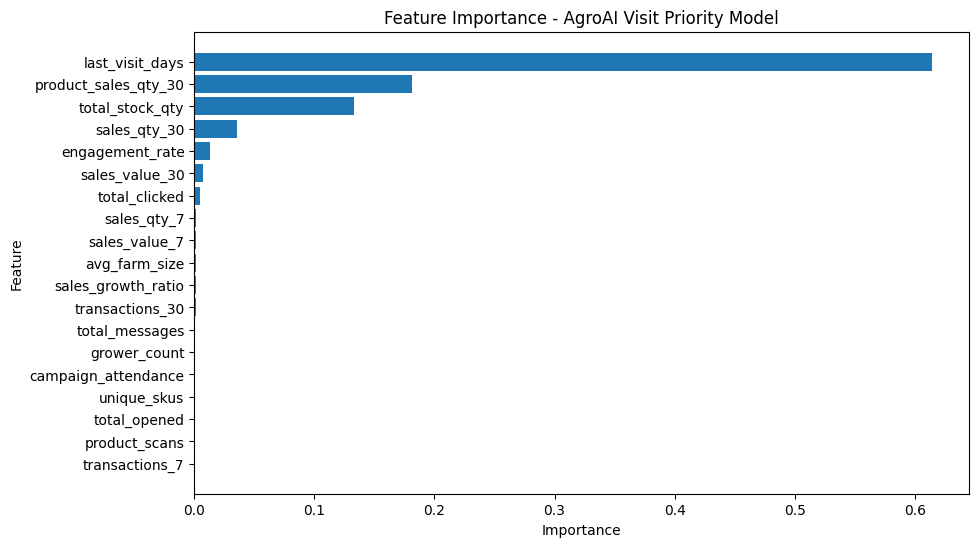

In [35]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - AgroAI Visit Priority Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# Prediction Function

In [36]:
def predict_visit_priority(input_data):
    input_df = pd.DataFrame([input_data])

    for col in features:
        if col not in input_df.columns:
            input_df[col] = 0

    input_df = input_df[features].fillna(0)

    score = reg_model.predict(input_df)[0]
    level = clf_model.predict(input_df)[0]

    if level == "High":
        action_type = "urgent"
    elif level == "Medium":
        action_type = "planned"
    else:
        action_type = "monitor"

    return {
        "visit_priority_score": round(float(score), 2),
        "priority_level": level,
        "action_type": action_type
    }

# Test Prediction Function

In [37]:
sample_input = {
    "sales_qty_30": 120,
    "sales_value_30": 50000,
    "transactions_30": 25,
    "sales_qty_7": 40,
    "sales_value_7": 18000,
    "transactions_7": 8,
    "sales_growth_ratio": 0.35,
    "total_stock_qty": 10,
    "unique_skus": 4,
    "last_visit_days": 22,
    "product_sales_qty_30": 80,
    "grower_count": 150,
    "avg_farm_size": 3.2,
    "product_scans": 40,
    "campaign_attendance": 20,
    "total_messages": 200,
    "total_opened": 120,
    "total_clicked": 45,
    "engagement_rate": 0.22
}

predict_visit_priority(sample_input)

{'visit_priority_score': 39.75,
 'priority_level': 'Medium',
 'action_type': 'planned'}

# Backend-Ready JSON

In [38]:
top_recommendations = recommendations.head(10).copy()

backend_json = top_recommendations[[
    "retailer_id",
    "territory_id",
    "state",
    "district",
    "tehsil",
    "visit_priority_score",
    "priority_level",
    "recommended_product",
    "recommended_action",
    "explanation"
]].to_dict(orient="records")

backend_json

[{'retailer_id': 'RTL_01994',
  'territory_id': 'TER_0252',
  'state': 'Madhya Pradesh',
  'district': 'Ujjain',
  'tehsil': 'Ujjain_T093',
  'visit_priority_score': 79.2942892240279,
  'priority_level': 'High',
  'recommended_product': 'Amistar 250 SC',
  'recommended_action': 'Visit retailer urgently and discuss restocking of Amistar 250 SC.',
  'explanation': 'Recent sales demand is high | This area has not been visited recently | Recommended product has strong recent demand'},
 {'retailer_id': 'RTL_01592',
  'territory_id': 'TER_0201',
  'state': 'Uttar Pradesh',
  'district': 'Varanasi',
  'tehsil': 'Varanasi_T073',
  'visit_priority_score': 71.74074935732602,
  'priority_level': 'High',
  'recommended_product': 'Movondo',
  'recommended_action': 'Visit retailer urgently and discuss restocking of Movondo.',
  'explanation': 'Recent sales demand is high | Current retailer stock is low | This area has not been visited recently'},
 {'retailer_id': 'RTL_01681',
  'territory_id': 'TER_

# Save Model Files

In [39]:
master.to_csv("/kaggle/working/agroai_master_scored_data.csv", index=False)
recommendations.to_csv("/kaggle/working/agroai_recommendations.csv", index=False)
feature_importance.to_csv("/kaggle/working/agroai_feature_importance.csv", index=False)

print("CSV files saved successfully")

CSV files saved successfully


# Save Final CSV Files

In [40]:
master.to_csv("/kaggle/working/agroai_master_scored_data.csv", index=False)
recommendations.to_csv("/kaggle/working/agroai_recommendations.csv", index=False)
feature_importance.to_csv("/kaggle/working/agroai_feature_importance.csv", index=False)

print("CSV files saved successfully")

CSV files saved successfully


# Check Output Files

In [41]:
os.listdir("/kaggle/working")

['__notebook__.ipynb',
 'agroai_recommendations.csv',
 'agroai_master_scored_data.csv',
 'agroai_feature_importance.csv']

# Save Model Files 

In [42]:
import joblib
import os

joblib.dump(reg_model, "/kaggle/working/agroai_visit_priority_regressor.pkl")
joblib.dump(clf_model, "/kaggle/working/agroai_priority_classifier.pkl")
joblib.dump(features, "/kaggle/working/agroai_model_features.pkl")

print("Model files saved successfully")
print(os.listdir("/kaggle/working"))

Model files saved successfully
['__notebook__.ipynb', 'agroai_visit_priority_regressor.pkl', 'agroai_model_features.pkl', 'agroai_recommendations.csv', 'agroai_priority_classifier.pkl', 'agroai_master_scored_data.csv', 'agroai_feature_importance.csv']
